# Introduction

In the previous chapter, we discussed the various approaches to solve k-arm bandit problems. Here, we will implement some of those approaches and see their performances.

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class KarmedBandit:
    def __init__(self, epsilon, initial=0., stepsize=0.1, sample_averages=False, ucb_param=None):
        
        self.epsilon = epsilon
        self.initial = initial
        self.stepsize = stepsize
        self.sample_averages = sample_averages
        self.ucb_param = ucb_param

        #Assign some values
        self.time = 0
        self.true_reward = 0
        self.average_reward = 0
        #Assign indices by np.argmacSelecting 10 as karmed testbed values 
        self.indices = np.arange(10)
        # real reward for each action
        self.q_True = []
        # estimation for each action
        self.q_Est = np.zeros(10)
        # initilize action chosen times for each action
        self.actionCount = []

        # initialize real rewards with N(0,1) distribution and estimations with desired initial value
        for i in range(0, 10):
          random_num = np.random.randn()
          self.q_True.append(random_num + self.true_reward)
          self.q_Est[i] = initial
          self.actionCount.append(0)

        self.bestAction = np.argmax(self.q_True)

    def get_action(self):
      '''
      Get an action for the bandit to choose expore or eploit 
      '''
      # exploration
      if self.epsilon > 0:
        if np.random.binomial(1, self.epsilon) == 1:
          return np.random.choice(self.indices)

      # exploitation
      if self.ucb_param is not None:
        UCB_Est = self.q_Est + \
                     self.ucb_param * np.sqrt(np.log(self.time + 1) / (np.asarray(self.actionCount) + 1))
        return np.argmax(UCB_Est)
      #return the estimation value for each action   
      return np.argmax(self.q_Est)


    def take_action(self, action):
      '''
      take an action an update the estimation for the respective action
      '''
      # First, generate the reward
      reward = np.random.randn() + self.q_True[action]
      self.time += 1
      self.average_reward = (self.time - 1.0) / self.time * self.average_reward + reward / self.time
      self.actionCount[action] += 1

      if self.sample_averages:
        # using sampleaverages update the estimation
        self.q_Est[action] += 1.0 / self.actionCount[action] * (reward - self.q_Est[action])
      else:
        self.q_Est[action] += self.stepsize * (reward - self.q_Est[action])
        
      return reward


In [3]:
def main(nBandits, time, bandits):
  '''
  Calculate the best action counts and Reward averages

  '''
  best_action_count = []
  reward_average = []
  

  best_action_count = [np.zeros(time, dtype='float') for _ in range(0, len(bandits))]
  reward_average = [np.zeros(time, dtype='float') for _ in range(0, len(bandits))]
  
  for banditInd, bandit in enumerate(bandits):
    for i in range(0, nBandits):
      for t in range(0, time):
        action = bandit[i].get_action()
        reward = bandit[i].take_action(action)
        reward_average[banditInd][t] += reward
        if action == bandit[i].bestAction:
          best_action_count[banditInd][t] += 1

    best_action_count[banditInd] /= nBandits
    reward_average[banditInd] /= nBandits

  return best_action_count, reward_average

## Simple-Average method
This is a simple method of estimating the values of actions and using this estimation we can make action selection decision. It can be estimated by averaging the actually received rewards:

$$Q_t(a) \doteq \frac{\text{sum of rewards when } a \text{ taken prior to $t$}}{\text{no of times } a \text{ taken prior to $t$}}
\doteq \frac{\sum_{i=1}^{t-1} R_i. 1_{A_i=a}}{\sum_{i-1}^{t-1} 1_{A_i=a}}$$

$R_i$ is the reward at time-steps 

$i$, and $1_{predicate}$  denotes the random variable and will be one of the correct predicate result and 0 if false.
This method is also called a $sample-average$ method for estimating action values because each estimate averages the sample of relevant rewards. 

Now we will compare the greedy method with epsilon greedy methods. We will set the value of epsilon as 0.1 and 0.01 for  $\epsilon $-greedy methods. We will use sample average techniques to estimates the action value.

In [4]:
# Compare greedy method with epsilon greedy method
def epsilonGreedy(nBandits, time):
  '''
  Comparision between the greedy method i.e epsilon = 0 with 
  two epsilon greedy method i.e epsilon = 0.1 and 0.01
  '''
  epsilons = [0, 0.1, 0.01]
  bandits = []
  for epsInd, eps in enumerate(epsilons):
    bandits.append([KarmedBandit(epsilon=eps, sample_averages=True) for _ in range(0, nBandits)])
  best_action_count, reward_average = main(nBandits, time, bandits)
    
    #Visualize First Figure
  plt.figure(1)
  for eps, counts in zip(epsilons, best_action_count):
    plt.plot(counts, label='epsilon = '+str(eps))
  plt.xlabel('Steps')
  plt.ylabel('% optimal action')
  plt.legend()

  #Visualize Second figure 
  plt.figure(2)
  for eps, rewards in zip(epsilons, reward_average):
    plt.plot(rewards, label='epsilon = '+str(eps))
  plt.xlabel('Steps')
  plt.ylabel('average reward')
  plt.legend()
  plt.show()

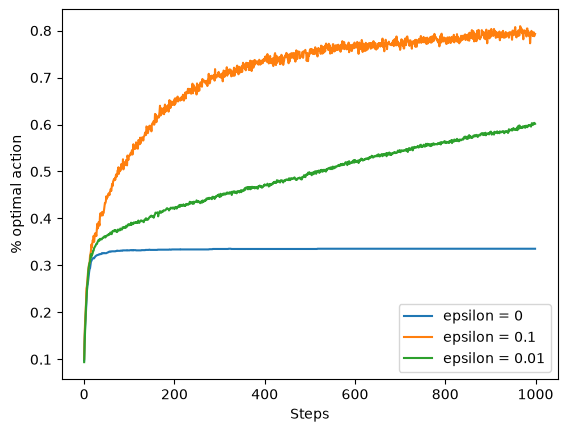

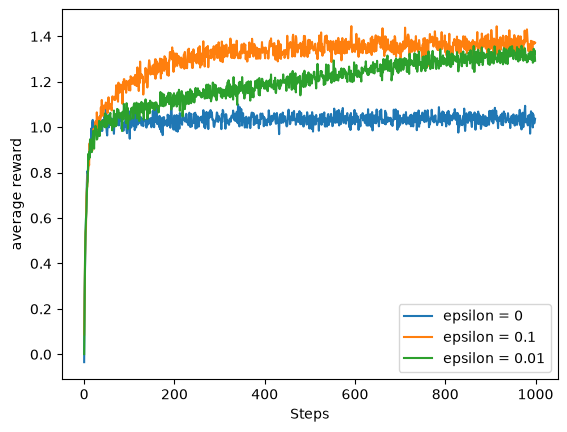

In [5]:
#Visualize the graph
epsilonGreedy(2000, 1000)

To see the performance of greedy and $\epsilon$-greedy, the data are averaged over 2000 runs with different bandit problems. The above figure shows the optimal action with increasing steps.
The lower figure shows the reward increases with the experiences. The greedy method performs slightly faster than the other methods and is worst in the long run.


## Upper Confidence Bound(UCB)
One of the way to balancing the exploration and exploitation problem is UCB action selection. Exploration needs to be done because of uncertainty about the action-value estimates. The ε greedy selection performs better than greedy selection; however, it is not the best one. It has no preferences among the non-greedy action; it just randomly selects one of them. So, selecting among the non-greedy actions with respect to their potential to be actually optimal would be a better choice.

UCB performs with the following relation.

$$A_t \doteq \text{argmax} [Q_t(a) + c\sqrt{\frac{ln(t)}{N_t(a)}}]$$

where $c$ controls the degree of exploration and $N_t(a)$ denotes number of times action $a$ has selected prior to $t$. The main idea of this (UCB) method is that the square-root term, $\sqrt {\frac{ln(t)}{N_t(a)}}$ measures uncertainty or variance  in the estimate  of a's value and $c$ determine the confidence level. 

In [6]:

def upper_confidence_bound(nBandits, time):
    bandits = [[], []]
    bandits[0] = [KarmedBandit(epsilon=0, stepsize=0.1, ucb_param=2) for _ in range(0, nBandits)]
    bandits[1] = [KarmedBandit(epsilon=0.1, stepsize=0.1) for _ in range(0, nBandits)]
    _, reward_average = main(nBandits, time, bandits)

    plt.figure(3)
    plt.plot(reward_average[0], label='UCB c = 2')
    plt.plot(reward_average[1], label='epsilon greedy, epsilon = 0.1')
    plt.xlabel('Steps')
    plt.ylabel('Average reward')
    plt.legend()
    plt.show()

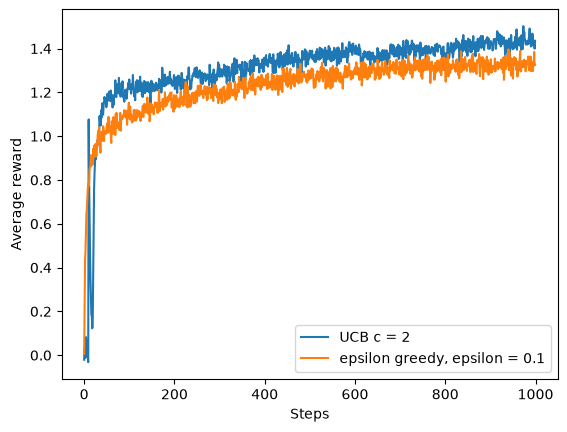

In [7]:
upper_confidence_bound(2000, 1000)


The above graph shows the performance of UCB action selection. We can see the UCB performs better than $\epsilon$-greedy.

## Optimistic Initial Values

All the methods we have discussed are somehow dependent on initial action-value estimates, $Q_t(a)$. Therefore, it is good to approach to initialize $Q_t(a)$ to some value.Since, it encourages exploration.

Note: For more you can check the reading material of K-arm Bandits Problem.

In [8]:
def optimistic_initial_values(nBandits, time):
    bandits = [[], []]
    bandits[0] = [KarmedBandit(epsilon=0, initial=5, stepsize=0.1) for _ in range(0, nBandits)]
    bandits[1] = [KarmedBandit(epsilon=0.1, initial=0, stepsize=0.1) for _ in range(0, nBandits)]
    # print(bandits[0])
    best_action_count, _ = main(nBandits, time, bandits)

    #For visualization
    plt.figure()
    plt.plot(best_action_count[0], label='Opmistic_greedy, epsilon = 0, q = 5')
    plt.plot(best_action_count[1], label='Realistic_epsilon-greedy, epsilon = 0.1, q = 0')
    plt.xlabel('Steps')
    plt.ylabel('% optimal action')
    plt.legend()
    plt.show()

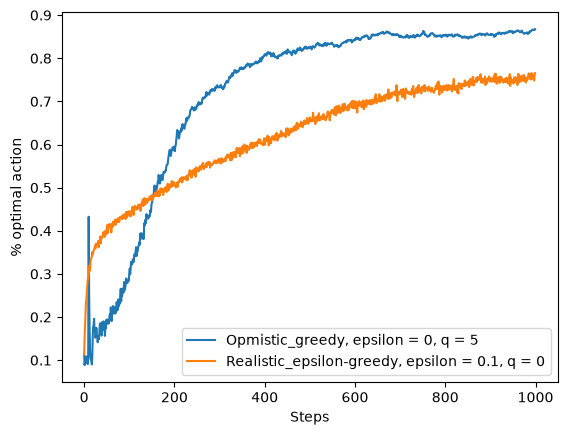

In [9]:
optimistic_initial_values(2000, 1000)


The above graph compare the performances of greedy method using $Q_1(a)=5, \epsilon=0$ with $\epsilon$-greedy method using $Q_1(a)=0, \epsilon=0.1$.

You can see, at first, the optimistic methods perform worse because it explores more.Later, it start performing better. This approach can be useful for encouraging early exploration. Optimistic Initial values are significant in stationary problems. They are not significant to non-stationary problems because the exploration is temporary i.e., if the distribution changes we need to explore again.